In [ ]:
#Supermarket sales dataset: GOAL
"""Use Case: Enhancing Retail Insights through Big Data Analytics
Background

A retail chain with multiple supermarket branches (A, B, C) across different cities wants to understand sales performance, customer behavior, and profitability trends.
Although each branch generates only a few thousand daily transactions, together they produce massive data every month.
Using computational analysis, the management aims to:

Identify top-selling product lines.
Analyze customer trends by gender and city.
Detect anomalies (outliers) in sales or ratings.
Improve profit margins through better decision-making."""

'Use Case: Enhancing Retail Insights through Big Data Analytics\nBackground\n \nA retail chain with multiple supermarket branches (A, B, C) across different cities wants to understand sales performance, customer behavior, and profitability trends.\nAlthough each branch generates only a few thousand daily transactions, together they produce massive data every month.\nUsing computational analysis, the management aims to:\n \nIdentify top-selling product lines.\nAnalyze customer trends by gender and city.\nDetect anomalies (outliers) in sales or ratings.\nImprove profit margins through better decision-making.'

In [ ]:
#Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_sales=pd.read_csv('/content/supermarket_sales.csv')

In [ ]:
df_sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
#Basic Dataset overview steps, head(), info(), describe(), isnull().sum()
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [ ]:
df_sales.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [ ]:
df_sales.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


In [ ]:
#Convert Date and Time Columns into Datetime Datatype
df_sales['Date']=pd.to_datetime(df_sales['Date'])
df_sales['Time']=pd.to_datetime(df_sales['Time'])

/tmp/ipython-input-3608943883.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sales['Time']=pd.to_datetime(df_sales['Time'])


In [ ]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   datetime64[ns]
 12  Payment                  1000 non-n

In [ ]:
#Outlier detection and removal for a clean dataset
#Q1,Q3,IQR---- LowerBound , Upper Bound.

numerical_cols=df_sales.select_dtypes(include=['number']).columns
numerical_cols

Index(['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs',
       'gross margin percentage', 'gross income', 'Rating'],
      dtype='object')

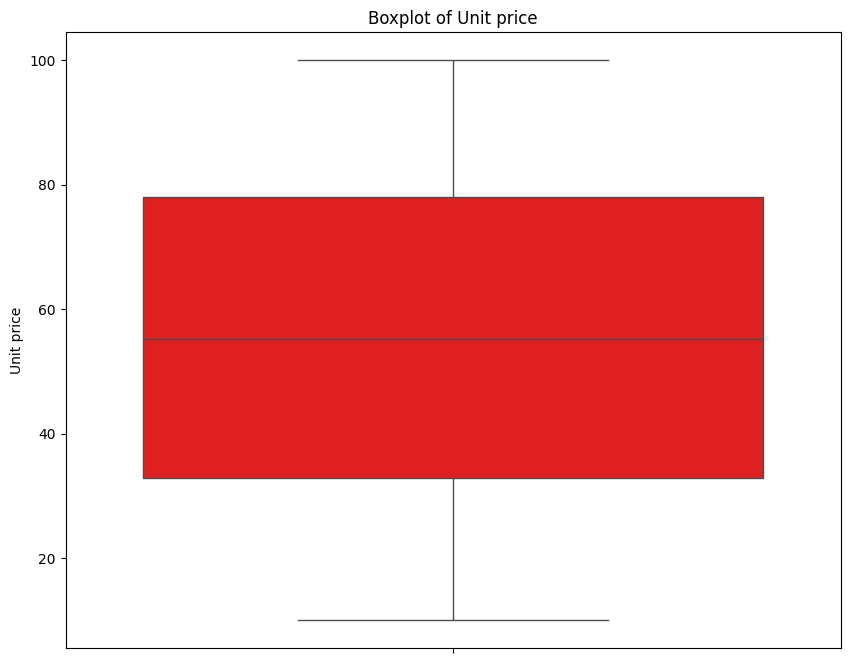

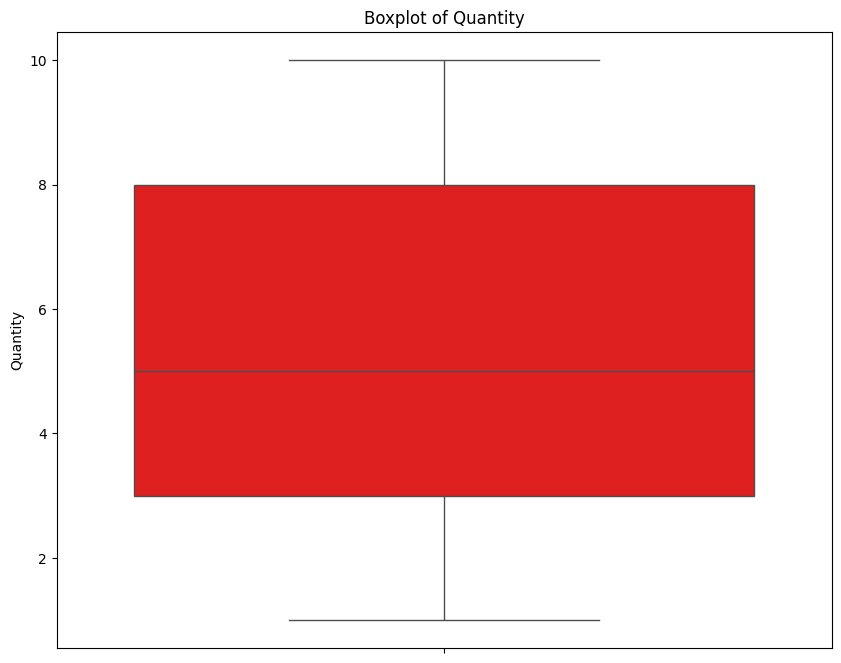

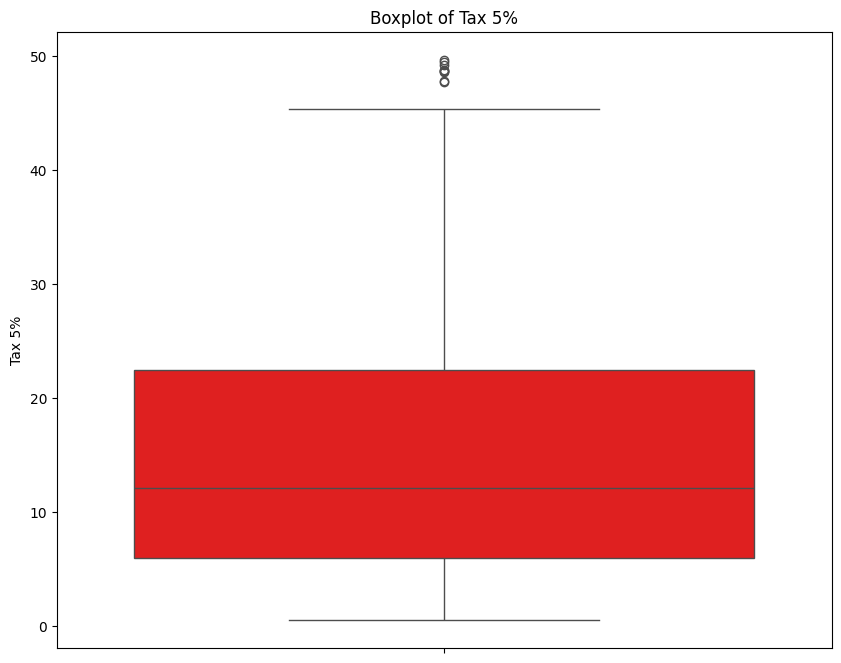

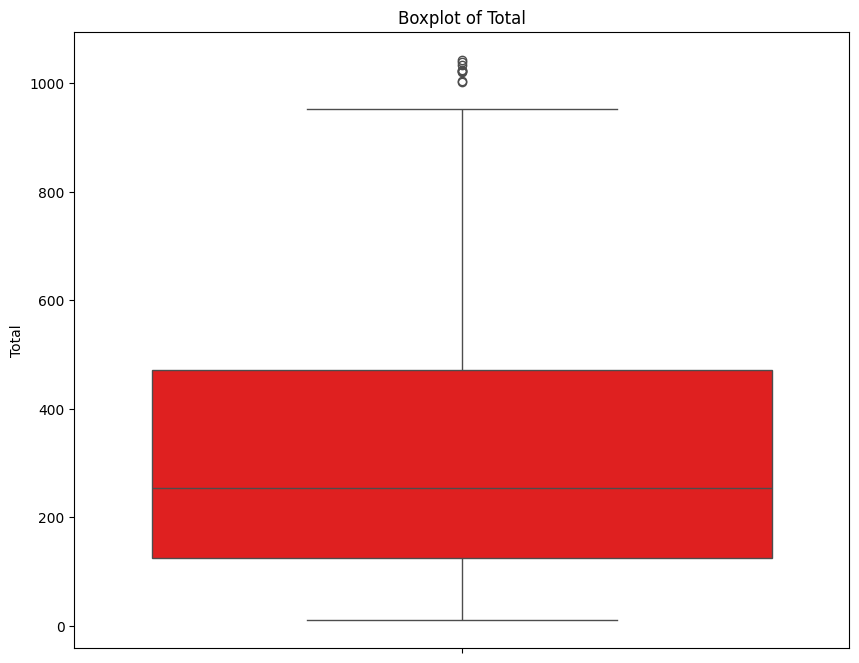

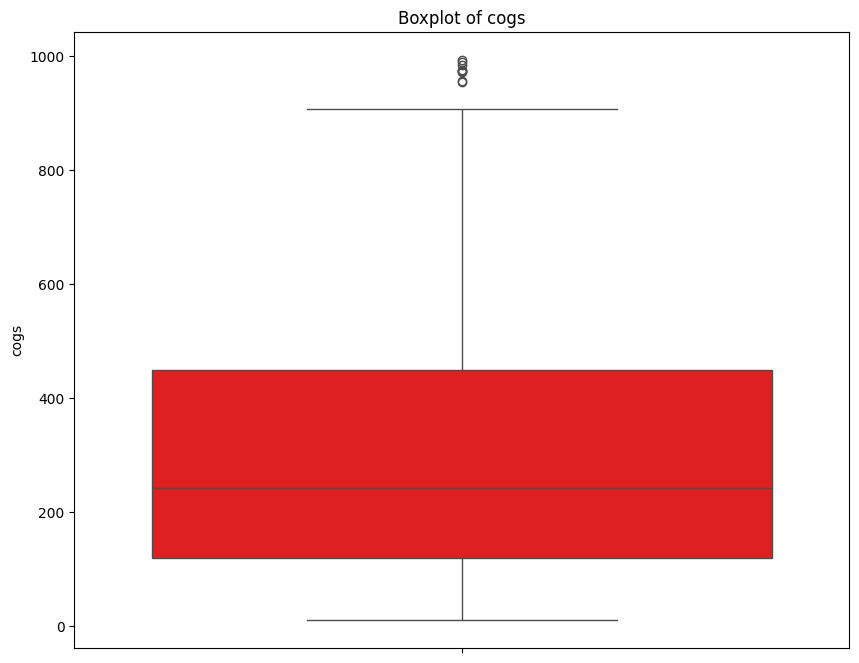

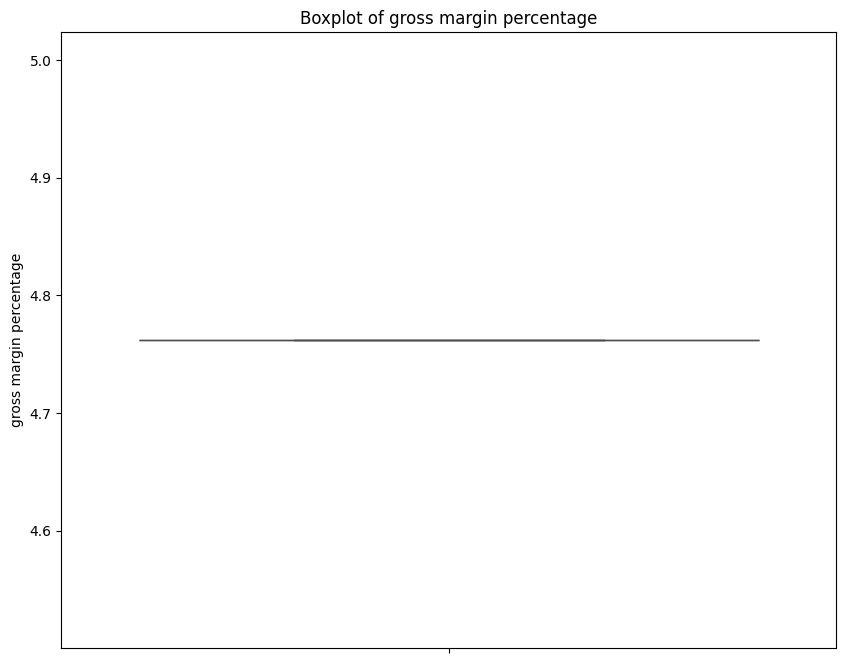

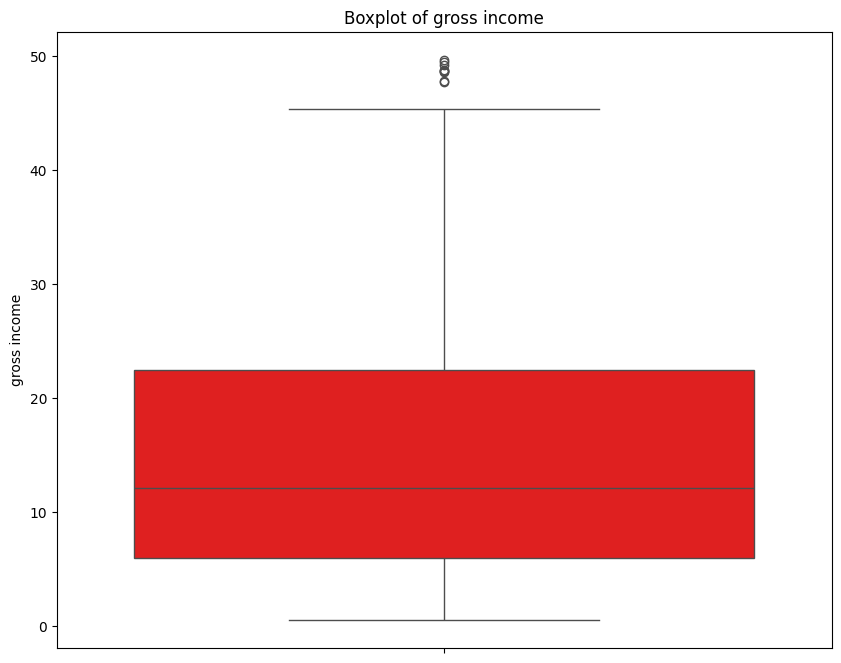

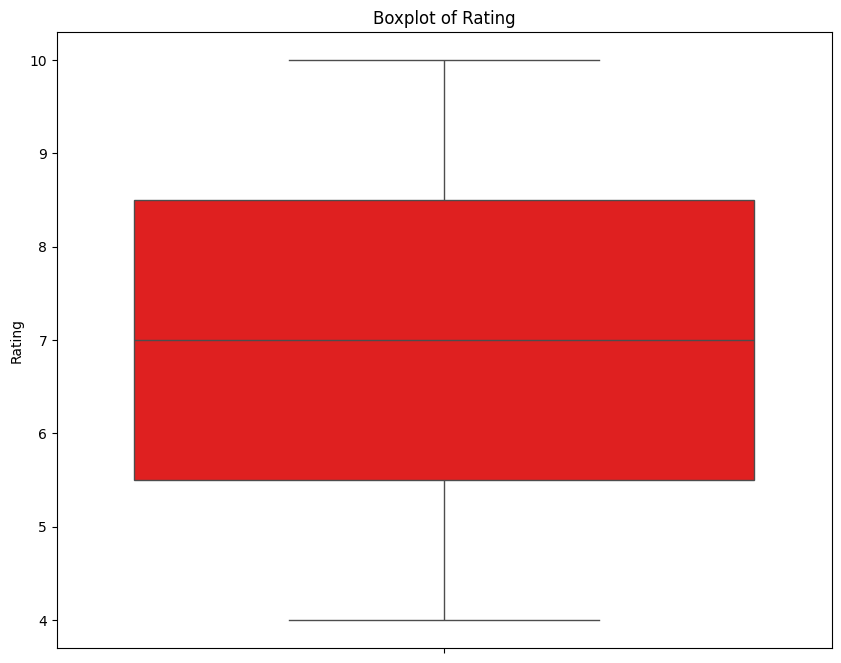

In [ ]:
for col in numerical_cols:
  plt.figure(figsize=(10,8))
  sns.boxplot(y=df_sales[col], color='red')
  plt.title(f'Boxplot of {col}')
  plt.show()

In [ ]:
#Function to identify and drop outliers using IQR
def drop_outliers_iqr(df, columns):
    for col in columns: #Q1, Q3, IQR.
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

        print(f"Number of outliers in '{col}':", len(outliers))

        # Drop outliers
        df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]
    return df

# Select numerical columns for outlier detection (excluding 'date')
numerical_cols = df_sales.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Apply the function to drop outliers
df_cleaned = drop_outliers_iqr(df_sales.copy(), numerical_cols)

print("\nShape of the original DataFrame:", df_sales.shape)
print("Shape of the DataFrame after dropping outliers:", df_cleaned.shape)

Number of outliers in 'Unit price': 0
Number of outliers in 'Quantity': 0
Number of outliers in 'Tax 5%': 9
Number of outliers in 'Total': 0
Number of outliers in 'cogs': 0
Number of outliers in 'gross margin percentage': 0
Number of outliers in 'gross income': 0
Number of outliers in 'Rating': 0

Shape of the original DataFrame: (1000, 17)
Shape of the DataFrame after dropping outliers: (991, 17)


In [ ]:
def count_outliers(series):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1
  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR

        # Identify outliers
  outliers = series[(series < lower_limit) | (series > upper_limit)]
  return outliers.count()

oc={col: count_outliers(df_sales[col]) for col in numerical_cols}

oc_df=pd.DataFrame(list(oc.items()), columns=['Column','Count'])
oc_df



,Column,Count
0,Unit price,0
1,Quantity,0
2,Tax 5%,9
3,Total,9
4,cogs,9
5,gross margin percentage,0
6,gross income,9
7,Rating,0


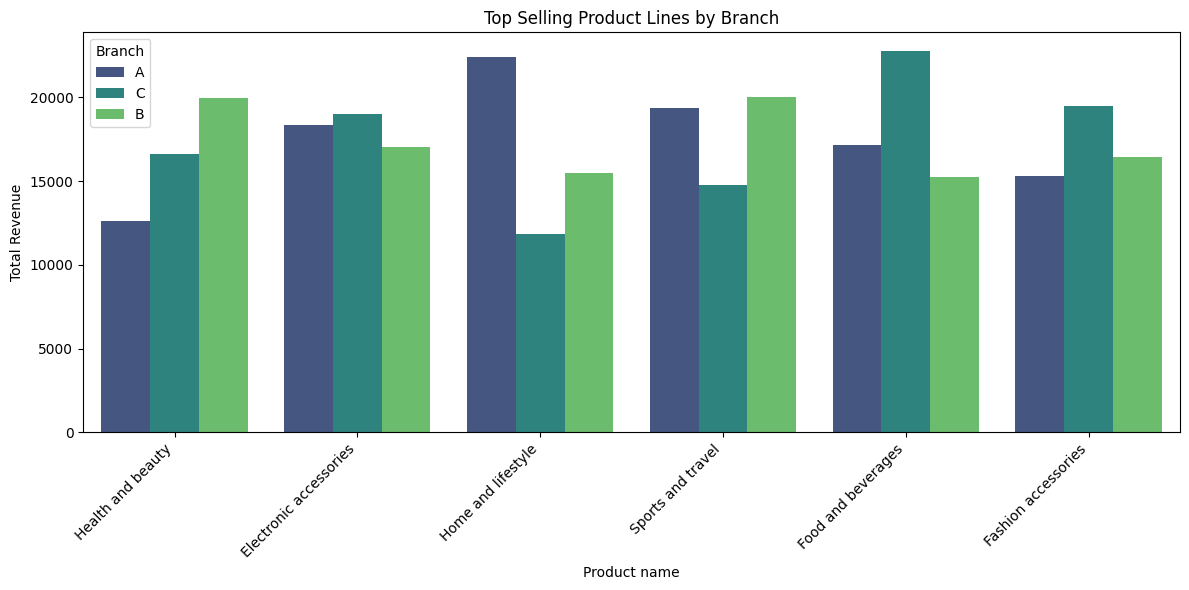

In [ ]:
#Dataset name hereafter: df_cleaned
#Identifying top selling product line.
plt.figure(figsize=(12,6))
sns.barplot(x='Product line', y='Total', data=df_cleaned, estimator='sum', hue='Branch', palette='viridis', errorbar=None)
plt.title('Top Selling Product Lines by Branch')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Product name')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2236366738.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Gender', y='Total', data=df_cleaned, estimator='sum', hue='City', ci=None)


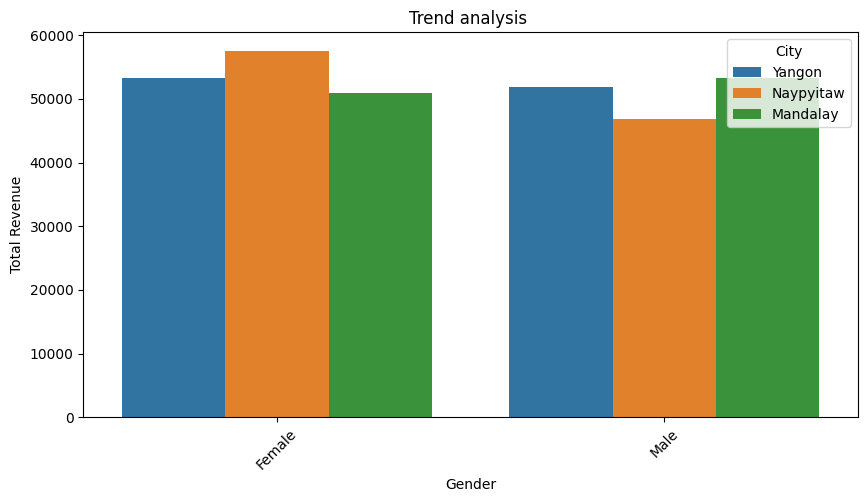

In [ ]:
#Customer Trends by Gender and City
plt.figure(figsize=(10,5))
sns.barplot(x='Gender', y='Total', data=df_cleaned, estimator='sum', hue='City', ci=None)
plt.title('Trend analysis ')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.xlabel('Gender')
plt.show()

In [ ]:
df_cleaned['Hour']=df_cleaned['Time'].dt.hour

/tmp/ipython-input-2430270446.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Hour', y='Total', data=df_cleaned, estimator='sum', color='blue', ci=None)


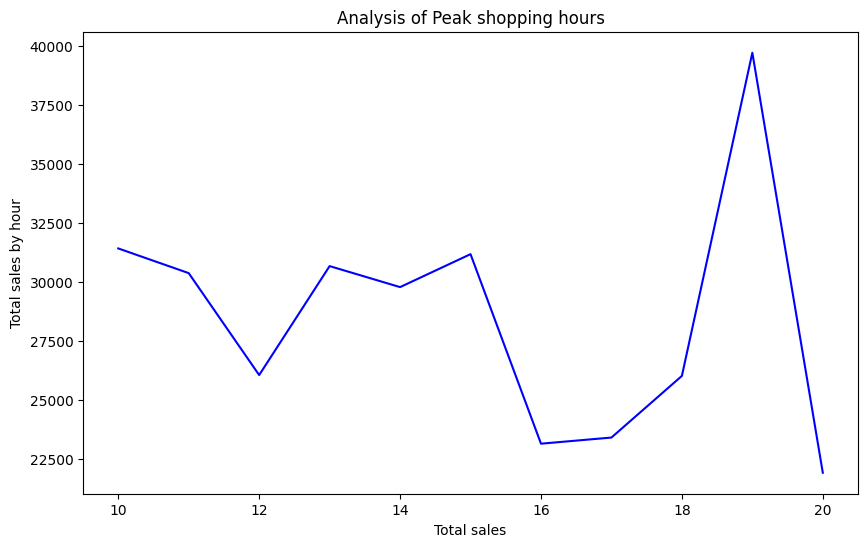

In [ ]:
#Analysis of peak shopping hours
plt.figure(figsize=(10,6))
sns.lineplot(x='Hour', y='Total', data=df_cleaned, estimator='sum', color='blue', ci=None)
plt.title('Analysis of Peak shopping hours')
plt.ylabel('Total sales by hour')
#plt.xticks()
plt.xlabel('Total sales')
plt.show()

/tmp/ipython-input-839871688.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Branch', y='Total', data=df_cleaned, estimator='sum', ci=None)


<Axes: xlabel='Branch', ylabel='Total'>

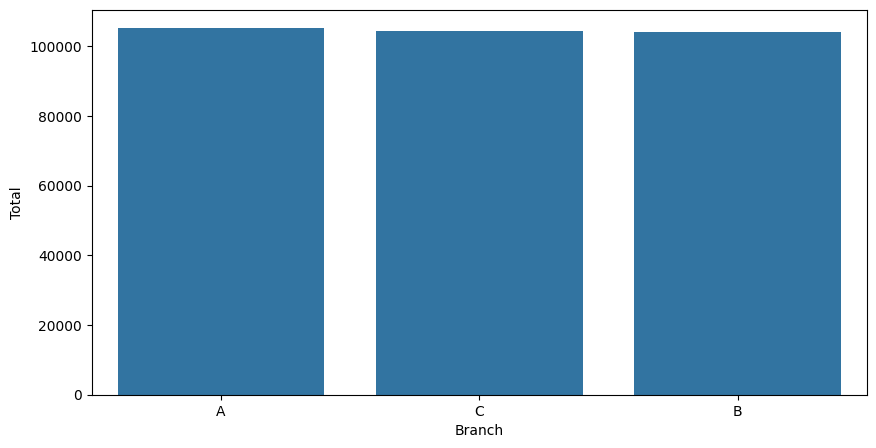

In [ ]:
#Branch wise total distribution
plt.figure(figsize=(10,5))
sns.barplot(x='Branch', y='Total', data=df_cleaned, estimator='sum', ci=None)